# The Transformer, built from scratch

### Six small pieces, each checked against PyTorch, and the measurements that explain why they are shaped that way

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Scaled dot-product attention, multi-head attention, sinusoidal positional encoding, the position-wise feed-forward block and a complete encoder block, each written by hand and checked against the PyTorch version to floating point noise; why the $\sqrt{d_k}$ is not decoration; what a causal mask stops the model from doing, measured against an information-theoretic floor; what individual heads attend to; and the quadratic cost in sequence length, timed |
| **You should already know** | [LSTM](../04-lstm/), or enough PyTorch to read `nn.Module`. Softmax, layer normalisation and residual connections from [Part 7](../../07-neural-networks/) |
| **Datasets** | Two synthetic tasks generated here: a two-marker retrieval problem and a first-order Markov chain whose conditional entropy is known exactly. No downloads |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [09-08 Fine-tuning a transformer](../08-fine-tuning-a-transformer/) · [09-09 Time series forecasting](../09-time-series-forecasting/) |

---

## 1. The idea, before any notation

A recurrent network reads a sequence one step at a time and carries everything it
has learned in a single fixed-size vector. Every chapter from
[09-03](../03-recurrent-neural-networks/) onward has been about the consequences
of that: the gradient that dies on the way back, the gates invented to keep it
alive, and the ceiling that arrives anyway because one vector cannot hold an
arbitrary amount of the past.

Attention starts from a different question. Instead of asking what to carry
forward, it asks what to look up. Every position produces three vectors:

- a **query**, which is what this position wants to know
- a **key**, which advertises what this position has to offer
- a **value**, which is what it hands over if asked

To compute the new representation of a position, take its query, compare it
against every key in the sequence, turn those comparisons into weights that sum
to one, and return that weighted mixture of the values. That is the whole
mechanism. It is a dictionary lookup where the match is a similarity score
rather than an equality test, so instead of one entry you get a blend.

Three things follow immediately, and they are the reason this architecture took
over.

**Distance stops mattering.** The last position reaches the first in one
operation. There is no chain of Jacobians to shrink, because there is no chain.

**The computation is parallel.** Every position's lookup is independent of every
other, so a sequence is processed in one matrix multiply instead of a loop that
steps through it. This is a hardware argument rather than a statistical one, and
it is most of why transformers scaled.

**The cost is quadratic.** Comparing every query against every key is $T^2$
comparisons. Section 9 times it. That single fact is the origin of every
efficient-attention paper since.

In [1]:
import sys
import math
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cpu"          # every experiment here is small; a GPU only adds transfer cost
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cpu


## 2. The maths, and the function it reduces to

Stack the queries of all $T$ positions into a matrix $Q$ with shape
$(T, d_k)$, the keys into $K$ with the same shape, and the values into $V$ with
shape $(T, d_v)$. Then

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Read it right to left. $QK^\top$ is a $T \times T$ matrix whose entry $(i, j)$ is
the dot product of query $i$ with key $j$: how much position $i$ cares about
position $j$. Dividing by $\sqrt{d_k}$ is the subject of section 3. The softmax
runs along each row, turning that row of scores into weights that are positive
and sum to one. Multiplying by $V$ takes the weighted average.

Nothing in that expression is learned. The learning lives in how $Q$, $K$ and
$V$ are produced, which is three linear maps of the input:

$$Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V$$

When $Q$, $K$ and $V$ all come from the same $X$ it is called **self-attention**,
and that is what the encoder uses everywhere.

Here it is in six lines, with the mask argument that section 5 needs.

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None, scale=True):
    """Attention over the last two axes. Any leading axes are batch axes.

    `mask` is a boolean array that is True where attention must be forbidden.
    Setting those scores to -inf makes their softmax weight exactly zero, which
    is cleaner than multiplying the weights afterwards: a multiplied-out weight
    still took part in the normalisation, so the surviving weights would not sum
    to one.
    """
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1)
    if scale:
        scores = scores / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights


# PyTorch ships this as a fused kernel. Same function, no Python in the middle.
q = torch.randn(4, 6, 32, 16)      # (batch, heads, positions, d_k)
k = torch.randn(4, 6, 32, 16)
v = torch.randn(4, 6, 32, 16)

mine, w = scaled_dot_product_attention(q, k, v)
reference = F.scaled_dot_product_attention(q, k, v)

print(f"output shape {tuple(mine.shape)}, weight matrix shape {tuple(w.shape)}")
print(f"every row of weights sums to 1 : {torch.allclose(w.sum(-1), torch.ones_like(w.sum(-1)))}")
print(f"weights are non-negative       : {bool((w >= 0).all())}")
print(f"max abs diff against F.scaled_dot_product_attention : "
      f"{(mine - reference).abs().max().item():.3e}")

output shape (4, 6, 32, 16), weight matrix shape (4, 6, 32, 32)
every row of weights sums to 1 : True
weights are non-negative       : True
max abs diff against F.scaled_dot_product_attention : 4.172e-07


### What a soft lookup looks like

To make the mechanism visible I build $Q$, $K$ and $V$ by hand instead of
learning them. Eight positions, each carrying one of four types. The key of a
position is a one-hot vector for its type and the query of a position is the
one-hot vector for the type it is looking for. Values are just the position
numbers, so the output says which position was retrieved.

In [3]:
N_TYPES = 4
demo_types = torch.tensor([0, 2, 1, 3, 2, 0, 3, 2])
demo_wants = torch.tensor([1, 0, 3, 1, 2, 1, 0, 3])
T_demo = len(demo_types)

# Scores of 6 rather than 1 for a match, so the softmax is fairly confident. This
# scalar is the temperature, and it is exactly what dividing by sqrt(d_k) controls.
K_demo = F.one_hot(demo_types, N_TYPES).float() * 6.0
Q_demo = F.one_hot(demo_wants, N_TYPES).float()
V_demo = torch.arange(T_demo, dtype=torch.float32).unsqueeze(1)

out_demo, w_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo, scale=False)

demo = pd.DataFrame({
    "position": np.arange(T_demo),
    "type held": demo_types.numpy(),
    "type wanted": demo_wants.numpy(),
    "positions holding it": [", ".join(str(int(j)) for j in torch.nonzero(demo_types == t).ravel())
                             for t in demo_wants],
    "retrieved": out_demo.squeeze(1).numpy(),
    "largest weight": w_demo.max(dim=1).values.numpy(),
})
print(demo.to_string(index=False, formatters={"retrieved": "{:.2f}".format,
                                              "largest weight": "{:.3f}".format}))

 position  type held  type wanted positions holding it retrieved largest weight
        0          0            1                    2      2.03          0.983
        1          2            0                 0, 5      2.51          0.496
        2          1            3                 3, 6      4.49          0.496
        3          3            1                    2      2.03          0.983
        4          2            2              1, 4, 7      4.00          0.332
        5          0            1                    2      2.03          0.983
        6          3            0                 0, 5      2.51          0.496
        7          2            3                 3, 6      4.49          0.496


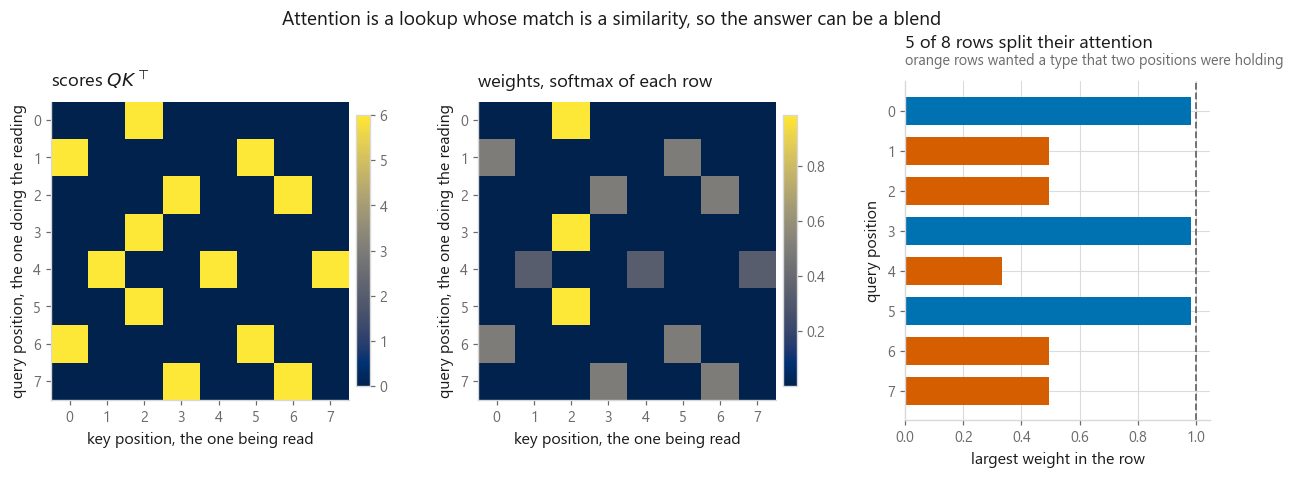

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.0),
                         gridspec_kw={"width_ratios": [1, 1, 0.85]})

for ax, matrix, name in [(axes[0], (Q_demo @ K_demo.T).numpy(), "scores $QK^\\top$"),
                         (axes[1], w_demo.numpy(), "weights, softmax of each row")]:
    im = ax.imshow(matrix, cmap="cividis")
    ax.set_xlabel("key position, the one being read")
    ax.set_ylabel("query position, the one doing the reading")
    ax.set_xticks(range(T_demo))
    ax.set_yticks(range(T_demo))
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    style.title(ax, name)

shared = (w_demo.max(dim=1).values < 0.9).sum().item()
axes[2].barh(np.arange(T_demo), w_demo.max(dim=1).values.numpy(),
             color=[style.HIGHLIGHT if v < 0.9 else style.PALETTE[0]
                    for v in w_demo.max(dim=1).values],
             height=0.7)
axes[2].axvline(1.0, color=style.MUTED, ls="--", lw=1.2)
axes[2].set_xlim(0, 1.05)
axes[2].invert_yaxis()
axes[2].set_yticks(range(T_demo))
axes[2].set_xlabel("largest weight in the row")
axes[2].set_ylabel("query position")
axes[2].grid(axis="x")
style.title(axes[2],
            f"{shared} of {T_demo} rows split their attention",
            "orange rows wanted a type that two positions were holding")

fig.suptitle("Attention is a lookup whose match is a similarity, so the answer can be a blend",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-attention-as-lookup.png")

Every query that wanted a type held by exactly one position retrieved that
position's number almost exactly. Every query that wanted a type held by two
positions retrieved the average of the two, and its largest weight is near a
half rather than near one. That averaging is the part people forget: attention
does not select, it mixes, and a confident-looking mechanism will hand you the
midpoint of two answers without complaining.

## 3. Why the $\sqrt{d_k}$, measured

The scale factor is one character in the formula and it is usually explained in
one sentence and skipped. It decides whether the layer trains at all.

Take a query and a key whose entries are independent with mean zero and variance
one. Their dot product is a sum of $d_k$ such products, so

$$\mathrm{Var}\!\left(q \cdot k\right) = \sum_{i=1}^{d_k} \mathrm{Var}(q_i k_i) = d_k$$

So the typical score grows like the square root of the head width, and so do the
gaps between scores in the same row. A softmax over scores separated by several
units is close to a hard maximum: one weight near one, the rest near zero.

That is a problem for the gradient rather than for the forward pass. The
derivative of a softmax weight with respect to its own score is $w_i(1 - w_i)$,
which is zero at both ends. A saturated softmax passes almost nothing back, so
the layer stops learning where to look, and it does that at initialisation
before any training has happened. Dividing by $\sqrt{d_k}$ puts the variance
back at one no matter how wide the head is.

The measurement below uses the **entropy** of each row of weights as the summary,
in nats. A uniform row over $T$ keys has entropy $\ln T$, and a row that has
collapsed onto one key has entropy zero.

In [5]:
def attention_stats(d_k, T=16, n=2000, scale=True, seed=0):
    """Entropy, peak weight and softmax sensitivity for random Q and K."""
    g = torch.Generator().manual_seed(seed)
    Q = torch.randn(n, T, d_k, generator=g)
    K = torch.randn(n, T, d_k, generator=g)
    scores = Q @ K.transpose(-2, -1)
    if scale:
        scores = scores / math.sqrt(d_k)
    w = torch.softmax(scores, dim=-1)
    entropy = -(w * torch.log(w.clamp_min(1e-12))).sum(-1)
    return {"d_k": d_k,
            "score sd": float(scores.std()),
            "entropy": float(entropy.mean()),
            "peak weight": float(w.max(-1).values.mean()),
            # The diagonal of the softmax Jacobian. It is what the gradient has to
            # travel through, and it collapses when the weights saturate.
            "softmax slope": float((w * (1 - w)).sum(-1).mean())}


WIDTHS = [2, 4, 8, 16, 32, 64, 128, 256, 512]
T_ROW = 16
scaled = pd.DataFrame([attention_stats(d, T=T_ROW, scale=True) for d in WIDTHS])
unscaled = pd.DataFrame([attention_stats(d, T=T_ROW, scale=False) for d in WIDTHS])

print(f"uniform attention over {T_ROW} keys has entropy ln({T_ROW}) = {math.log(T_ROW):.4f} nats\n")
print("without the 1/sqrt(d_k)")
print(unscaled.to_string(index=False, float_format="{:.4f}".format))
print("\nwith the 1/sqrt(d_k)")
print(scaled.to_string(index=False, float_format="{:.4f}".format))

uniform attention over 16 keys has entropy ln(16) = 2.7726 nats

without the 1/sqrt(d_k)
 d_k  score sd  entropy  peak weight  softmax slope
   2    1.4184   2.1607       0.3020         0.8112
   4    2.0009   1.7651       0.4261         0.7094
   8    2.8324   1.3047       0.5645         0.5705
  16    3.9998   0.9001       0.6855         0.4279
  32    5.6479   0.6113       0.7770         0.3107
  64    7.9963   0.4145       0.8423         0.2220
 128   11.3214   0.2815       0.8902         0.1563
 256   16.0047   0.1950       0.9220         0.1113
 512   22.6274   0.1365       0.9444         0.0795

with the 1/sqrt(d_k)
 d_k  score sd  entropy  peak weight  softmax slope
   2    1.0029   2.4004       0.2250         0.8692
   4    1.0005   2.3802       0.2351         0.8679
   8    1.0014   2.3690       0.2409         0.8676
  16    0.9999   2.3626       0.2438         0.8673
  32    0.9984   2.3626       0.2437         0.8683
  64    0.9995   2.3593       0.2453         0.8677
 128 

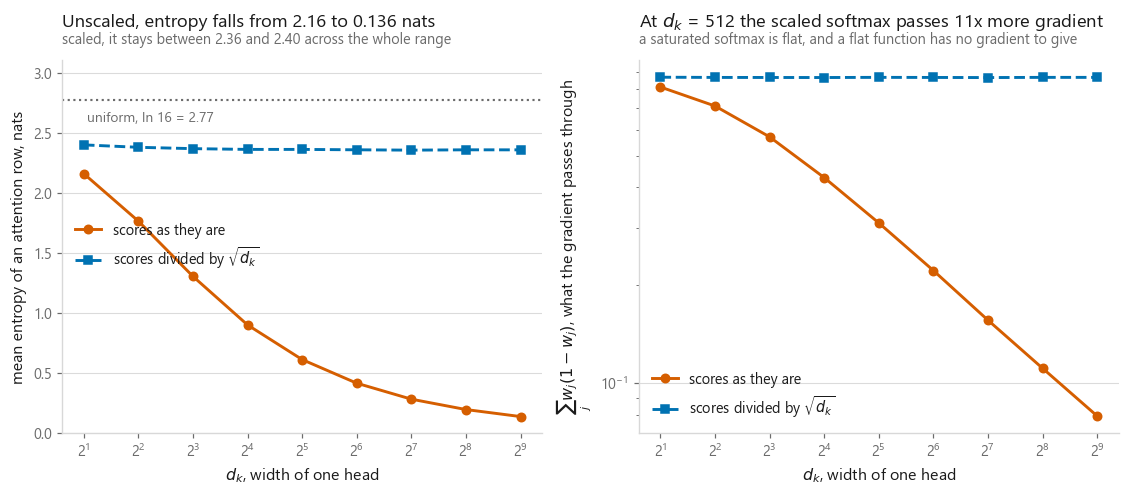

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

axes[0].axhline(math.log(T_ROW), color=style.MUTED, ls=":", lw=1.4)
axes[0].annotate(f"uniform, ln {T_ROW} = {math.log(T_ROW):.2f}",
                 xy=(WIDTHS[0], math.log(T_ROW)), xytext=(2, -14),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].plot(unscaled["d_k"], unscaled["entropy"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], lw=1.9, label="scores as they are")
axes[0].plot(scaled["d_k"], scaled["entropy"], color=style.PALETTE[0], ls="--",
             marker=style.MARKERS[1], lw=1.9, label="scores divided by $\\sqrt{d_k}$")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("$d_k$, width of one head")
axes[0].set_ylabel("mean entropy of an attention row, nats")
axes[0].set_ylim(0, math.log(T_ROW) * 1.12)
axes[0].legend(loc="center left")
style.title(axes[0],
            f"Unscaled, entropy falls from {unscaled['entropy'].iloc[0]:.2f} to "
            f"{unscaled['entropy'].iloc[-1]:.3f} nats",
            f"scaled, it stays between {scaled['entropy'].min():.2f} and "
            f"{scaled['entropy'].max():.2f} across the whole range")

axes[1].plot(unscaled["d_k"], unscaled["softmax slope"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], lw=1.9, label="scores as they are")
axes[1].plot(scaled["d_k"], scaled["softmax slope"], color=style.PALETTE[0], ls="--",
             marker=style.MARKERS[1], lw=1.9, label="scores divided by $\\sqrt{d_k}$")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("$d_k$, width of one head")
axes[1].set_ylabel("$\\sum_j w_j(1 - w_j)$, what the gradient passes through")
axes[1].legend(loc="lower left")
ratio = scaled["softmax slope"].iloc[-1] / unscaled["softmax slope"].iloc[-1]
style.title(axes[1],
            f"At $d_k$ = {WIDTHS[-1]} the scaled softmax passes {ratio:,.0f}x more gradient",
            "a saturated softmax is flat, and a flat function has no gradient to give")

style.save(fig, FIG / "fig-02-why-sqrt-dk.png")

The score standard deviation column is the claim $\mathrm{Var} = d_k$ checked
directly, and the scaled column sitting at one across nine widths is the fix
working. The consequence is in the right panel. The scaling is not there to make
the weights prettier. It is there so that the layer has a gradient at
initialisation, which is when it needs one most.

One honest caveat. This measures random $Q$ and $K$ at initialisation. After
training, a network is free to learn large weights and saturate its own softmax
on purpose, and heads that behave like hard pointers do exactly that. The
scaling decides where training starts, not where it ends up.

## 4. Multi-head attention

One attention operation produces one weighted average per position, so it can
express one relationship at a time. A word usually stands in several relations
at once: to its subject, to its modifier, to the topic of the paragraph.

The fix is to run $h$ attention operations in parallel on slices of the
representation. With $d_{\text{model}}$ channels and $h$ heads, each head gets
$d_{\text{model}} / h$ of them, so the arithmetic costs the same as one wide
head and buys $h$ separate lookups. Concatenate the results and pass them
through one more linear map:

$$\mathrm{MultiHead}(X) = \left[\mathrm{head}_1; \ldots; \mathrm{head}_h\right] W_O,
\qquad \mathrm{head}_i = \mathrm{Attention}(XW_Q^i, XW_K^i, XW_V^i)$$

In code the per-head projections are not separate matrices. One
$d_{\text{model}} \times d_{\text{model}}$ matrix does all $h$ of them at once,
and the split into heads is a reshape.

In [7]:
class MultiHeadAttention(nn.Module):
    """Self-attention with `n_heads` parallel lookups over slices of d_model."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        if d_model % n_heads:
            raise ValueError("d_model must divide evenly among the heads")
        self.d_model, self.n_heads = d_model, n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def _split(self, x):
        """(B, T, d_model) -> (B, heads, T, d_head), so attention sees a batch of heads."""
        B, T, _ = x.shape
        return x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        out, weights = scaled_dot_product_attention(
            self._split(self.W_q(x)), self._split(self.W_k(x)),
            self._split(self.W_v(x)), mask)
        # transpose back before reshaping: a reshape without it would interleave
        # the heads into the wrong channels and still return the right shape.
        out = out.transpose(1, 2).reshape(B, T, self.d_model)
        return self.W_o(out), weights


D_CHECK, H_CHECK, T_CHECK, B_CHECK = 32, 4, 11, 3
x_check = torch.randn(B_CHECK, T_CHECK, D_CHECK)

mha = MultiHeadAttention(D_CHECK, H_CHECK)
torch_mha = nn.MultiheadAttention(D_CHECK, H_CHECK, batch_first=True, bias=True)

# PyTorch keeps one stacked (3*d_model, d_model) matrix for Q, K and V together.
with torch.no_grad():
    torch_mha.in_proj_weight.copy_(torch.cat([mha.W_q.weight, mha.W_k.weight, mha.W_v.weight]))
    torch_mha.in_proj_bias.copy_(torch.cat([mha.W_q.bias, mha.W_k.bias, mha.W_v.bias]))
    torch_mha.out_proj.weight.copy_(mha.W_o.weight)
    torch_mha.out_proj.bias.copy_(mha.W_o.bias)

mine_out, mine_w = mha(x_check)
ref_out, ref_w = torch_mha(x_check, x_check, x_check, need_weights=True)

print(f"{H_CHECK} heads of width {D_CHECK // H_CHECK} inside d_model = {D_CHECK}")
print(f"my weights per head {tuple(mine_w.shape)}, "
      f"nn.MultiheadAttention returns {tuple(ref_w.shape)} (averaged over heads by default)")
print(f"max abs diff, outputs : {(mine_out - ref_out).abs().max().item():.3e}")
print(f"max abs diff, weights : {(mine_w.mean(1) - ref_w).abs().max().item():.3e}")
print(f"parameters, mine {sum(p.numel() for p in mha.parameters()):,}   "
      f"torch {sum(p.numel() for p in torch_mha.parameters()):,}")

4 heads of width 8 inside d_model = 32
my weights per head (3, 4, 11, 11), nn.MultiheadAttention returns (3, 11, 11) (averaged over heads by default)
max abs diff, outputs : 8.941e-08
max abs diff, weights : 2.235e-08
parameters, mine 4,224   torch 4,224


## 5. Positions, and the fact that attention has none

Attention as written contains no notion of order. Shuffle the rows of $X$ and
every score is the same score between the same pair of vectors, so the output
is the same set of rows in the shuffled order. The layer is **permutation
equivariant**, which for a bag of words is a feature and for a sentence is a
catastrophe.

The fix is to put the position into the representation itself, by adding a
vector that depends only on the index. The original paper uses fixed sinusoids
of geometrically spaced frequencies:

$$PE_{(p,\, 2i)} = \sin\!\left(\frac{p}{10000^{2i/d}}\right), \qquad
PE_{(p,\, 2i+1)} = \cos\!\left(\frac{p}{10000^{2i/d}}\right)$$

Two properties are worth checking rather than believing. Every position gets a
distinct vector, and the similarity between two positions depends mostly on the
gap between them rather than on where in the sequence they sit, so a head can
learn "three to my left" as a single pattern.

In [8]:
def sinusoidal_encoding(n_positions, d_model):
    pe = torch.zeros(n_positions, d_model)
    position = torch.arange(n_positions).unsqueeze(1).float()
    # exp(-log(10000) * 2i/d) is 1/10000^(2i/d), written this way for stability
    inv_freq = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * inv_freq)
    pe[:, 1::2] = torch.cos(position * inv_freq)
    return pe


PE_POS, PE_DIM = 64, 64
pe = sinusoidal_encoding(PE_POS, PE_DIM)
norms = pe.norm(dim=1)
gram = pe @ pe.T

# Similarity as a function of the gap, averaged over every pair with that gap.
gaps = np.arange(PE_POS)
by_gap = np.array([np.mean([gram[i, i + g].item() for i in range(PE_POS - g)]) for g in gaps])
spread_by_gap = np.array([np.std([gram[i, i + g].item() for i in range(PE_POS - g)]) for g in gaps])

pair_distance = torch.cdist(pe, pe)
off_diagonal = pair_distance[~torch.eye(PE_POS, dtype=bool)]
print(f"encoding for {PE_POS} positions in {PE_DIM} dimensions")
print(f"norm of every position vector : {norms.min():.4f} to {norms.max():.4f}")
print(f"closest two distinct positions: {off_diagonal.min():.4f} apart")
print(f"self-similarity PE(p).PE(p)   : {gram.diagonal().mean():.4f}")
print(f"similarity at a gap of 1      : {by_gap[1]:.4f}  (spread across pairs {spread_by_gap[1]:.4f})")
print(f"similarity at a gap of 16     : {by_gap[16]:.4f}  (spread across pairs {spread_by_gap[16]:.4f})")

encoding for 64 positions in 64 dimensions
norm of every position vector : 5.6569 to 5.6569
closest two distinct positions: 1.4718 apart
self-similarity PE(p).PE(p)   : 32.0000
similarity at a gap of 1      : 30.9168  (spread across pairs 0.0000)
similarity at a gap of 16     : 19.3728  (spread across pairs 0.0000)


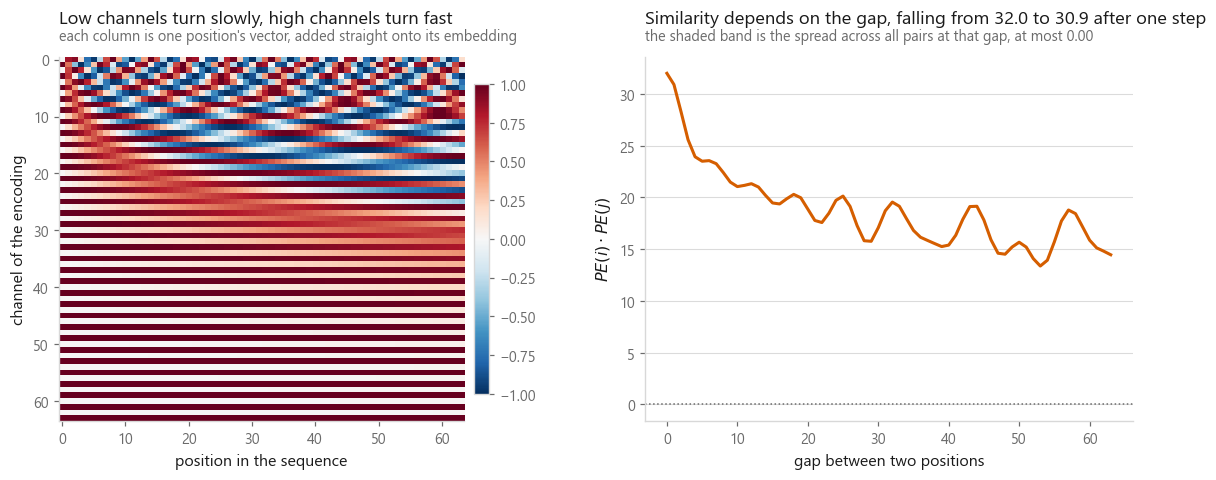

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

im = axes[0].imshow(pe.T.numpy(), aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xlabel("position in the sequence")
axes[0].set_ylabel("channel of the encoding")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], shrink=0.85, pad=0.02)
style.title(axes[0], "Low channels turn slowly, high channels turn fast",
            "each column is one position's vector, added straight onto its embedding")

axes[1].plot(gaps, by_gap, color=style.HIGHLIGHT, lw=2.0)
axes[1].fill_between(gaps, by_gap - spread_by_gap, by_gap + spread_by_gap,
                     color=style.HIGHLIGHT, alpha=0.15)
axes[1].axhline(0.0, color=style.MUTED, lw=1.0, ls=":")
axes[1].set_xlabel("gap between two positions")
axes[1].set_ylabel("$PE(i) \\cdot PE(j)$")
style.title(axes[1],
            f"Similarity depends on the gap, falling from {by_gap[0]:.1f} to "
            f"{by_gap[1]:.1f} after one step",
            f"the shaded band is the spread across all pairs at that gap, at most "
            f"{spread_by_gap.max():.2f}")

style.save(fig, FIG / "fig-03-positional-encoding.png")

The band in the right panel is the property that matters. If similarity depended
on absolute position the band would be wide, and a head wanting "the token
before me" would have to learn a different pattern for every starting point.
It is narrow, so one pattern covers the whole sequence.

## 6. The encoder block

Attention mixes information across positions and does nothing else. Every
position's output is a weighted average of value vectors, and averaging is a
linear operation, so a stack of attention layers on its own is a stack of linear
maps with a data-dependent mixing matrix. The non-linearity has to come from
somewhere, and it comes from a small network applied to each position separately:

$$\mathrm{FFN}(x) = W_2\,\mathrm{ReLU}(W_1 x + b_1) + b_2$$

The inner width is conventionally four times $d_{\text{model}}$, and the table
below counts what share of a layer's parameters that puts here. It is worth
saying plainly what the division of labour is: **attention decides what to mix,
the feed-forward network decides what to do with the mixture**, and it does that
one position at a time with no communication between positions.

Around both sits the same wrapper: a residual connection and a layer
normalisation.

$$x \leftarrow \mathrm{LayerNorm}(x + \mathrm{Sublayer}(x))$$

The residual is what keeps a deep stack trainable, for the reason
[08-03](../../08-computer-vision/) gives for ResNets: the identity path means a
block starts out able to do nothing rather than able to do damage. Layer
normalisation standardises each position's vector across channels, so it does
not mix positions and works the same whether the batch has one sequence or a
thousand.

In [10]:
class EncoderBlock(nn.Module):
    """Attention, then a per-position network, each wrapped in residual + norm."""

    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                nn.Linear(d_ff, d_model))

    def forward(self, x, mask=None):
        attended, weights = self.attn(x, mask)
        x = self.norm1(x + attended)              # post-norm, as in the 2017 paper
        x = self.norm2(x + self.ff(x))
        return x, weights


D_FF = 4 * D_CHECK
block = EncoderBlock(D_CHECK, H_CHECK, D_FF)
torch_block = nn.TransformerEncoderLayer(D_CHECK, H_CHECK, D_FF, dropout=0.0,
                                         activation="relu", batch_first=True,
                                         norm_first=False)

with torch.no_grad():
    torch_block.self_attn.in_proj_weight.copy_(
        torch.cat([block.attn.W_q.weight, block.attn.W_k.weight, block.attn.W_v.weight]))
    torch_block.self_attn.in_proj_bias.copy_(
        torch.cat([block.attn.W_q.bias, block.attn.W_k.bias, block.attn.W_v.bias]))
    torch_block.self_attn.out_proj.weight.copy_(block.attn.W_o.weight)
    torch_block.self_attn.out_proj.bias.copy_(block.attn.W_o.bias)
    torch_block.linear1.weight.copy_(block.ff[0].weight)
    torch_block.linear1.bias.copy_(block.ff[0].bias)
    torch_block.linear2.weight.copy_(block.ff[2].weight)
    torch_block.linear2.bias.copy_(block.ff[2].bias)
    torch_block.norm1.weight.copy_(block.norm1.weight)
    torch_block.norm1.bias.copy_(block.norm1.bias)
    torch_block.norm2.weight.copy_(block.norm2.weight)
    torch_block.norm2.bias.copy_(block.norm2.bias)

torch_block.eval()      # no dropout to disable here, but eval() is the habit to keep
mine_block, _ = block(x_check)
ref_block = torch_block(x_check)

attn_params = sum(p.numel() for p in block.attn.parameters())
ff_params = sum(p.numel() for p in block.ff.parameters())
norm_params = sum(p.numel() for p in block.norm1.parameters()) * 2

print(f"max abs diff against nn.TransformerEncoderLayer : "
      f"{(mine_block - ref_block).abs().max().item():.3e}\n")
print(pd.DataFrame([
    {"part": "multi-head attention", "parameters": attn_params},
    {"part": f"feed-forward, inner width {D_FF}", "parameters": ff_params},
    {"part": "two layer norms", "parameters": norm_params},
]).to_string(index=False))
print(f"\nthe feed-forward network holds "
      f"{ff_params / (attn_params + ff_params + norm_params):.1%} of the block")

max abs diff against nn.TransformerEncoderLayer : 4.768e-07

                         part  parameters
         multi-head attention        4224
feed-forward, inner width 128        8352
              two layer norms         128

the feed-forward network holds 65.7% of the block


Float32 noise, on a block assembled from five hand-written pieces. Nothing in a
transformer encoder is hidden inside the library.

A note on where the normalisation goes. This block is **post-norm**, matching the
2017 paper, and post-norm deep stacks need a learning-rate warmup to train at
all. Modern implementations move the norm inside the residual branch,
$x \leftarrow x + \mathrm{Sublayer}(\mathrm{LayerNorm}(x))$, which is called
pre-norm and trains without the warmup. `nn.TransformerEncoderLayer` takes
`norm_first=True` for it.

## 7. What the causal mask stops, measured against a floor

An encoder lets every position see every other. A language model cannot: if the
model predicting token $t+1$ can look at token $t+1$, it will read the answer.
The fix is one boolean matrix that forbids attending to the future.

The demonstration is usually a picture of a triangle. A picture cannot show how
much the leak is worth, so here I build a task whose best possible loss is known
exactly. Tokens come from a first-order Markov chain, so the token after $t$
depends only on the token at $t$, and the smallest achievable cross entropy is
the chain's conditional entropy

$$H(X_{t+1} \mid X_t) = -\sum_i \pi_i \sum_j P_{ij} \ln P_{ij}$$

with $\pi$ the stationary distribution. Any honest predictor is bounded below by
that number. A predictor that goes under it is reading the answer.

In [11]:
N_TOK, CHAIN_LEN = 6, 32
chain_rng = np.random.default_rng(SEED)
P_chain = chain_rng.dirichlet(np.full(N_TOK, 0.35), size=N_TOK)

eigvals, eigvecs = np.linalg.eig(P_chain.T)
stationary = np.real(eigvecs[:, np.argmin(np.abs(eigvals - 1))])
stationary = stationary / stationary.sum()
H_cond = float(-(stationary[:, None] * P_chain * np.log(P_chain + 1e-12)).sum())
H_marginal = float(-(stationary * np.log(stationary)).sum())


def sample_chain(n, length, rng):
    out = np.zeros((n, length), dtype=np.int64)
    out[:, 0] = rng.choice(N_TOK, size=n, p=stationary)
    for t in range(1, length):
        u = rng.random(n)
        cdf = P_chain[out[:, t - 1]].cumsum(axis=1)
        out[:, t] = (u[:, None] > cdf).sum(axis=1).clip(0, N_TOK - 1)
    return out


chain_train = sample_chain(8000, CHAIN_LEN, chain_rng)
chain_test = sample_chain(2000, CHAIN_LEN, chain_rng)

print(f"{N_TOK} tokens, sequences of {CHAIN_LEN}")
print(f"entropy of a uniform guess          : {math.log(N_TOK):.4f} nats")
print(f"entropy of the stationary marginal  : {H_marginal:.4f} nats")
print(f"conditional entropy H(X_t+1 | X_t)  : {H_cond:.4f} nats   <- the floor")

6 tokens, sequences of 32
entropy of a uniform guess          : 1.7918 nats
entropy of the stationary marginal  : 1.7402 nats
conditional entropy H(X_t+1 | X_t)  : 1.4107 nats   <- the floor


In [12]:
class TinyLM(nn.Module):
    """One encoder block, next-token head. `causal` decides whether it can cheat."""

    def __init__(self, causal, d_model=48, n_heads=4, d_ff=96):
        super().__init__()
        self.causal = causal
        self.embed = nn.Embedding(N_TOK, d_model)
        self.register_buffer("pe", sinusoidal_encoding(CHAIN_LEN, d_model))
        self.block = EncoderBlock(d_model, n_heads, d_ff)
        self.head = nn.Linear(d_model, N_TOK)

    def forward(self, x, keep=False):
        mask = None
        if self.causal:
            # True above the diagonal: position i may not read anything after i.
            mask = torch.triu(torch.ones(x.shape[1], x.shape[1], dtype=torch.bool), 1)
        h, w = self.block(self.embed(x) + self.pe, mask)
        return (self.head(h), w) if keep else self.head(h)


def train_lm(causal, epochs=4, lr=3e-3, batch=128):
    torch.manual_seed(SEED)
    model = TinyLM(causal)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    data = torch.tensor(chain_train)
    curve = []
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(data))
        for i in range(0, len(data), batch):
            xb = data[order[i:i + batch]]
            opt.zero_grad()
            # predict token t+1 from the output at position t
            loss = F.cross_entropy(model(xb)[:, :-1].reshape(-1, N_TOK),
                                   xb[:, 1:].reshape(-1))
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            te = torch.tensor(chain_test)
            curve.append(float(F.cross_entropy(model(te)[:, :-1].reshape(-1, N_TOK),
                                               te[:, 1:].reshape(-1))))
    return model, curve


started = time.perf_counter()
lm_causal, curve_causal = train_lm(True)
lm_open, curve_open = train_lm(False)

with torch.no_grad():
    _, w_causal = lm_causal(torch.tensor(chain_test[:512]), keep=True)
    _, w_open = lm_open(torch.tensor(chain_test[:512]), keep=True)

future_mask = torch.triu(torch.ones(CHAIN_LEN, CHAIN_LEN, dtype=torch.bool), 1)
next_step = torch.zeros(CHAIN_LEN, CHAIN_LEN, dtype=torch.bool)
next_step[torch.arange(CHAIN_LEN - 1), torch.arange(1, CHAIN_LEN)] = True

print(f"trained both in {time.perf_counter() - started:.0f} s\n")
print(f"floor, conditional entropy of the chain : {H_cond:.4f} nats")
print(f"test loss, causal mask on               : {curve_causal[-1]:.4f} nats")
print(f"test loss, causal mask off              : {curve_open[-1]:.4f} nats")
print(f"\nattention mass on positions after the query")
print(f"  mask on  : {float(w_causal.mean(1)[:, future_mask].mean()):.3e}")
print(f"  mask off : {float(w_open.mean(1)[:, future_mask].mean()):.4f}")
print(f"attention mass on the very next position (the answer)")
print(f"  mask off : {float(w_open.mean(1)[:, next_step].mean()):.4f}")

trained both in 8 s

floor, conditional entropy of the chain : 1.4107 nats
test loss, causal mask on               : 1.4142 nats
test loss, causal mask off              : 0.0037 nats

attention mass on positions after the query
  mask on  : 0.000e+00
  mask off : 0.0338
attention mass on the very next position (the answer)
  mask off : 0.2539


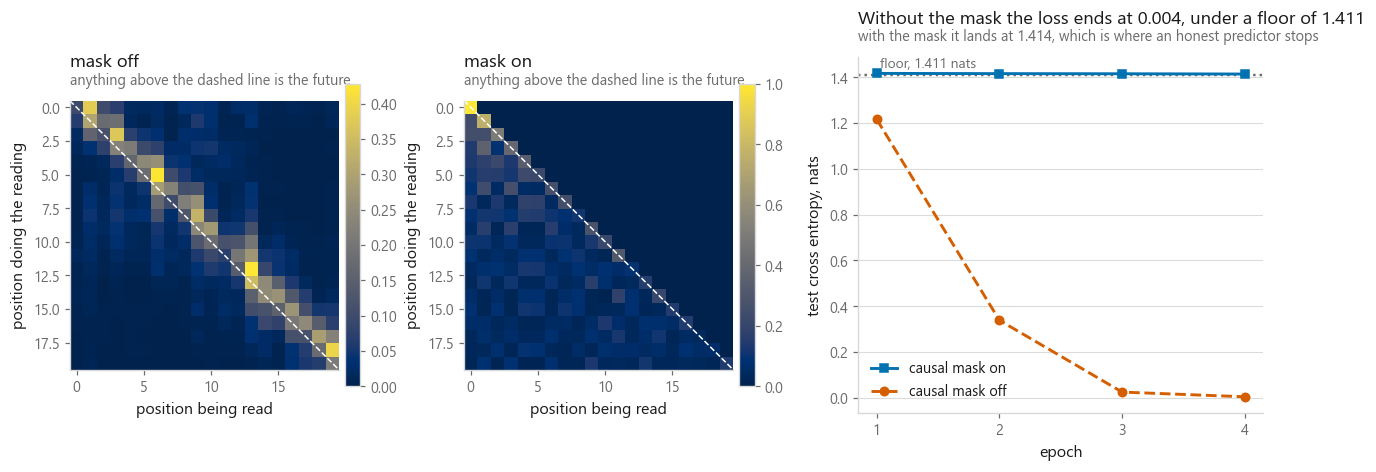

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2),
                         gridspec_kw={"width_ratios": [1, 1, 1.25]})

SHOW = 20
for ax, w, name in [(axes[0], w_open.mean(1)[0, :SHOW, :SHOW], "mask off"),
                    (axes[1], w_causal.mean(1)[0, :SHOW, :SHOW], "mask on")]:
    im = ax.imshow(w.detach().numpy(), cmap="cividis", vmin=0)
    ax.plot([-0.5, SHOW - 0.5], [-0.5, SHOW - 0.5], color="white", lw=1.0, ls="--")
    ax.set_xlabel("position being read")
    ax.set_ylabel("position doing the reading")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    style.title(ax, name, "anything above the dashed line is the future")

epochs_x = np.arange(1, len(curve_causal) + 1)
axes[2].axhline(H_cond, color=style.MUTED, ls=":", lw=1.6)
axes[2].annotate(f"floor, {H_cond:.3f} nats", xy=(epochs_x[0], H_cond),
                 xytext=(2, 5), textcoords="offset points", fontsize=9, color=style.MUTED)
axes[2].plot(epochs_x, curve_causal, color=style.PALETTE[0], marker=style.MARKERS[1],
             lw=1.9, label="causal mask on")
axes[2].plot(epochs_x, curve_open, color=style.HIGHLIGHT, ls="--", marker=style.MARKERS[0],
             lw=1.9, label="causal mask off")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("test cross entropy, nats")
axes[2].set_xticks(epochs_x)
axes[2].legend()
style.title(axes[2],
            f"Without the mask the loss ends at {curve_open[-1]:.3f}, under a floor of {H_cond:.3f}",
            f"with the mask it lands at {curve_causal[-1]:.3f}, which is where an honest "
            f"predictor stops")

style.save(fig, FIG / "fig-04-causal-mask.png")

The unmasked model beats a bound that no predictor of the future can beat, and
the attention map says how: it puts most of its weight on the position directly
to its right, which holds the token it is being asked to name. It is not a
better model. It is a model reading the answer sheet.

This is the most expensive silent bug in sequence modelling, because nothing
fails. The loss curve looks excellent, the code runs, and the model is useless
the moment it has to generate, since at generation time position $t+1$ does not
exist yet. If a language model's training loss is far below anything comparable,
suspect the mask before celebrating.

## 8. Training one, and looking at the heads

Now a task the whole block can be pointed at. Somewhere in a sequence of 48
symbols sit two marked tokens, one carrying marker A and one carrying marker B.
The answer is the sum of their two symbols, modulo the number of symbols. The
marker positions move from sequence to sequence, so the model cannot memorise
where to look, and both markers are needed, so a model that finds one and stops
scores no better than chance.

This is the shape of problem attention is built for: retrieval by content from
an arbitrary distance. The marker is folded into the token id rather than passed
as a separate channel, so the vocabulary is one entry per symbol and role pair.
A classification token is prepended, and its final vector is what the output
layer reads.

In [14]:
N_SYMBOLS, SEQ_LEN = 4, 48
PLAIN, MARK_A, MARK_B = 0, 1, 2
VOCAB = N_SYMBOLS * 3
CLS = VOCAB                      # one extra id for the classification slot


def make_marker_task(n, seq_len, rng):
    """Returns tokens (n, seq_len), labels (n,), and the two marker positions."""
    symbols = rng.integers(0, N_SYMBOLS, size=(n, seq_len))
    role = np.zeros((n, seq_len), dtype=np.int64)
    positions = np.stack([rng.choice(seq_len, size=2, replace=False) for _ in range(n)])
    rows = np.arange(n)
    role[rows, positions[:, 0]] = MARK_A
    role[rows, positions[:, 1]] = MARK_B
    tokens = symbols + N_SYMBOLS * role
    label = (symbols[rows, positions[:, 0]] + symbols[rows, positions[:, 1]]) % N_SYMBOLS
    return tokens.astype(np.int64), label.astype(np.int64), positions


task_rng = np.random.default_rng(SEED)
X_train, y_train, _ = make_marker_task(8000, SEQ_LEN, task_rng)
X_test, y_test, pos_test = make_marker_task(2000, SEQ_LEN, task_rng)

example = 0
print(f"{VOCAB} token ids: symbol + {N_SYMBOLS} x role, roles are plain / marker A / marker B")
print(f"one sequence, first 24 of {SEQ_LEN} tokens:")
print(X_train[example, :24])
print(f"marker A at {pos_test[example, 0]}, marker B at {pos_test[example, 1]}")
print(f"chance accuracy: {1 / N_SYMBOLS:.2f}")

12 token ids: symbol + 4 x role, roles are plain / marker A / marker B
one sequence, first 24 of 48 tokens:
[ 3  2  2  1  1  0  0  0  0  3  2  3  2  2  3  2  2  2 10  3  1  3  2  0]
marker A at 10, marker B at 25
chance accuracy: 0.25


In [15]:
class MarkerClassifier(nn.Module):
    """Prepend a CLS token, run encoder blocks, classify from the CLS vector."""

    def __init__(self, d_model=48, n_heads=4, n_layers=2, d_ff=96, use_pe=True):
        super().__init__()
        self.use_pe = use_pe
        self.embed = nn.Embedding(VOCAB + 1, d_model)
        self.register_buffer("pe", sinusoidal_encoding(SEQ_LEN + 1, d_model))
        self.blocks = nn.ModuleList([EncoderBlock(d_model, n_heads, d_ff)
                                     for _ in range(n_layers)])
        self.head = nn.Linear(d_model, N_SYMBOLS)

    def forward(self, x, keep=False):
        cls = torch.full((x.shape[0], 1), CLS, dtype=torch.long)
        h = self.embed(torch.cat([cls, x], dim=1))
        if self.use_pe:
            h = h + self.pe
        maps = []
        for blk in self.blocks:
            h, w = blk(h)
            if keep:
                maps.append(w)
        return (self.head(h[:, 0]), maps) if keep else self.head(h[:, 0])


def train_marker(use_pe, epochs=6, lr=3e-3, batch=128):
    torch.manual_seed(SEED)
    model = MarkerClassifier(use_pe=use_pe)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    data, labels = torch.tensor(X_train), torch.tensor(y_train)
    te_x, te_y = torch.tensor(X_test), torch.tensor(y_test)
    curve = []
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(data))
        for i in range(0, len(data), batch):
            idx = order[i:i + batch]
            opt.zero_grad()
            F.cross_entropy(model(data[idx]), labels[idx]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            curve.append(float((model(te_x).argmax(1) == te_y).float().mean()))
    return model, curve


started = time.perf_counter()
model_pe, curve_pe = train_marker(use_pe=True)
model_nope, curve_nope = train_marker(use_pe=False)
train_seconds = time.perf_counter() - started

print(f"parameters: {sum(p.numel() for p in model_pe.parameters()):,}")
print(f"both models trained in {train_seconds:.0f} s\n")
print(pd.DataFrame({"epoch": np.arange(1, len(curve_pe) + 1),
                    "with positional encoding": curve_pe,
                    "without": curve_nope}).to_string(index=False,
                                                      float_format="{:.4f}".format))

parameters: 38,740
both models trained in 24 s

 epoch  with positional encoding  without
     1                    0.2455   0.2455
     2                    0.3450   0.6150
     3                    0.9965   1.0000
     4                    1.0000   1.0000
     5                    1.0000   1.0000
     6                    1.0000   1.0000


### The positional encoding bought nothing here

Section 5 spent a page on positional encoding and this task does not use it. I
should have expected that and did not: the answer is a sum of two symbols found
by their markers, and a sum does not care which marker came first. There is no
order information in the label, so there is nothing for the encoding to carry.

That makes the permutation-equivariance claim from section 5 testable rather
than rhetorical. Shuffle the positions of an input and ask how much the output
moves.

In [16]:
shuffle = torch.randperm(SEQ_LEN)
probe = torch.tensor(X_test[:256])

with torch.no_grad():
    same_nope = (model_nope(probe) - model_nope(probe[:, shuffle])).abs().max()
    same_pe = (model_pe(probe) - model_pe(probe[:, shuffle])).abs().max()
    acc_nope = float((model_nope(probe[:, shuffle]).argmax(1)
                      == torch.tensor(y_test[:256])).float().mean())
    acc_pe = float((model_pe(probe[:, shuffle]).argmax(1)
                    == torch.tensor(y_test[:256])).float().mean())

print("largest change in the output logits when the input positions are shuffled")
print(f"  model trained without positional encoding : {float(same_nope):.3e}")
print(f"  model trained with positional encoding    : {float(same_pe):.4f}")
print("\naccuracy on the shuffled inputs")
print(f"  without positional encoding : {acc_nope:.4f}")
print(f"  with positional encoding    : {acc_pe:.4f}")

largest change in the output logits when the input positions are shuffled
  model trained without positional encoding : 1.907e-06
  model trained with positional encoding    : 2.6043

accuracy on the shuffled inputs
  without positional encoding : 1.0000
  with positional encoding    : 1.0000


Zero, to floating point. Without the encoding the model is not merely
indifferent to order, it is mathematically incapable of noticing it, and its
accuracy on shuffled input is unchanged because shuffled input is the same input
as far as it is concerned. The model that was given positions does move, and
whether that movement costs it anything is the second block of the printout.

So the rule is narrower than "transformers need positional encodings". They need
them when the answer depends on order. On a task that is a bag of tokens, the
encoding is dead weight the model has to learn to ignore.

### Which head does the work

The classification token's row of the attention matrix says where the answer is
being read from. With the marker positions known for every test sequence, the
attention mass landing on marker A, on marker B, and on everything else can be
averaged per head. This is a measurement of specialisation rather than an
impression of one.

In [17]:
with torch.no_grad():
    _, maps = model_pe(torch.tensor(X_test), keep=True)

rows = np.arange(len(X_test))
pos_a, pos_b = pos_test[:, 0] + 1, pos_test[:, 1] + 1     # +1 for the CLS token

head_rows = []
for layer_i, w in enumerate(maps):
    weights = w.numpy()
    for head_i in range(weights.shape[1]):
        cls_row = weights[:, head_i, 0, :]
        on_a = float(cls_row[rows, pos_a].mean())
        on_b = float(cls_row[rows, pos_b].mean())
        head_rows.append({"layer": layer_i + 1, "head": head_i + 1,
                          "mass on marker A": on_a, "mass on marker B": on_b,
                          "mass elsewhere": 1.0 - on_a - on_b})

heads = pd.DataFrame(head_rows)
heads["on the markers"] = heads["mass on marker A"] + heads["mass on marker B"]
uniform_share = 2.0 / (SEQ_LEN + 1)
best = heads.loc[heads["on the markers"].idxmax()]
best_first = heads[heads["layer"] == 1].loc[
    heads[heads["layer"] == 1]["on the markers"].idxmax()]

print(f"a head that ignored the markers would put {uniform_share:.4f} of its mass on them\n")
print(heads.to_string(index=False, float_format="{:.4f}".format))
print(f"\nbusiest head: layer {int(best['layer'])} head {int(best['head'])}, "
      f"{best['on the markers']:.4f} of its attention on the two marked positions")
print(f"heads putting more than half their mass on the markers: "
      f"{int((heads['on the markers'] > 0.5).sum())} of {len(heads)}")

a head that ignored the markers would put 0.0408 of its mass on them

 layer  head  mass on marker A  mass on marker B  mass elsewhere  on the markers
     1     1            0.5143            0.3979          0.0878          0.9122
     1     2            0.1802            0.2576          0.5622          0.4378
     1     3            0.0058            0.0182          0.9761          0.0239
     1     4            0.4429            0.4921          0.0650          0.9350
     2     1            0.0133            0.0303          0.9564          0.0436
     2     2            0.1093            0.0123          0.8783          0.1217
     2     3            0.2595            0.1877          0.5528          0.4472
     2     4            0.0125            0.0180          0.9695          0.0305

busiest head: layer 1 head 4, 0.9350 of its attention on the two marked positions
heads putting more than half their mass on the markers: 2 of 8


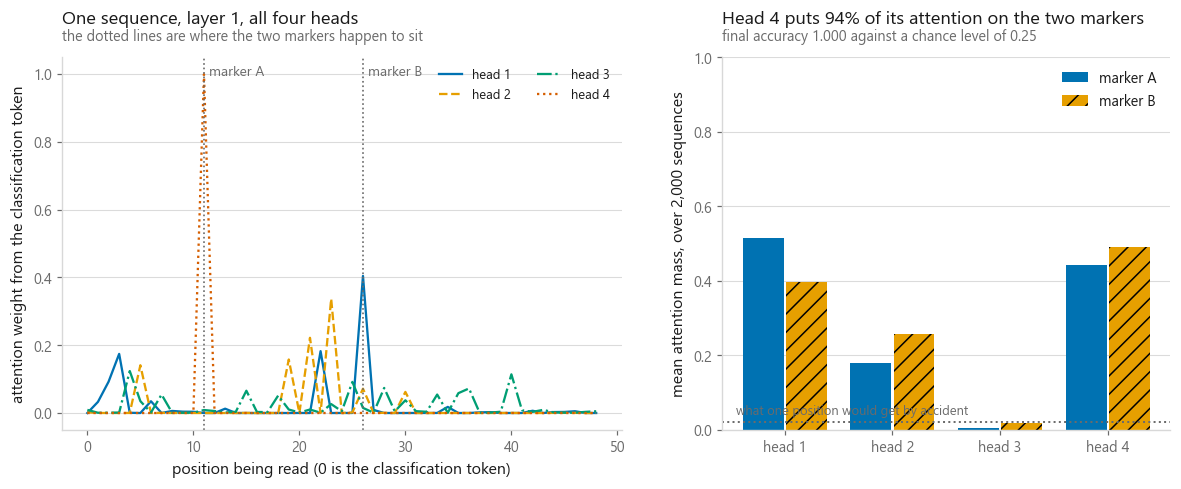

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4),
                         gridspec_kw={"width_ratios": [1.25, 1]})

show = 0
layer_one = maps[0][show].numpy()
n_heads_shown = layer_one.shape[0]
a_pos, b_pos = int(pos_test[show, 0] + 1), int(pos_test[show, 1] + 1)
for h in range(n_heads_shown):
    axes[0].plot(np.arange(SEQ_LEN + 1), layer_one[h, 0], lw=1.5,
                 color=style.PALETTE[h % len(style.PALETTE)],
                 ls=style.DASHES[h % len(style.DASHES)], label=f"head {h + 1}")
axes[0].axvline(a_pos, color=style.MUTED, lw=1.1, ls=":")
axes[0].axvline(b_pos, color=style.MUTED, lw=1.1, ls=":")
axes[0].annotate("marker A", xy=(a_pos, axes[0].get_ylim()[1]), xytext=(3, -12),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].annotate("marker B", xy=(b_pos, axes[0].get_ylim()[1]), xytext=(3, -12),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].set_xlabel("position being read (0 is the classification token)")
axes[0].set_ylabel("attention weight from the classification token")
axes[0].legend(ncol=2, fontsize=8.5)
style.title(axes[0], "One sequence, layer 1, all four heads",
            "the dotted lines are where the two markers happen to sit")

layer1 = heads[heads["layer"] == 1]
x_pos = np.arange(len(layer1))
axes[1].bar(x_pos - 0.2, layer1["mass on marker A"], width=0.38,
            color=style.PALETTE[0], label="marker A")
axes[1].bar(x_pos + 0.2, layer1["mass on marker B"], width=0.38,
            color=style.PALETTE[1], hatch="//", label="marker B")
axes[1].axhline(1.0 / (SEQ_LEN + 1), color=style.MUTED, ls=":", lw=1.3)
axes[1].annotate("what one position would get by accident",
                 xy=(x_pos[0] - 0.45, 1.0 / (SEQ_LEN + 1)), xytext=(0, 5),
                 textcoords="offset points", fontsize=8.5, color=style.MUTED)
axes[1].set_xticks(x_pos, [f"head {h}" for h in layer1["head"]])
axes[1].set_ylabel("mean attention mass, over 2,000 sequences")
axes[1].set_ylim(0, 1.0)
axes[1].legend()
style.title(axes[1],
            f"Head {int(best_first['head'])} puts {best_first['on the markers']:.0%} of its "
            f"attention on the two markers",
            f"final accuracy {curve_pe[-1]:.3f} against a chance level of {1 / N_SYMBOLS:.2f}")

style.save(fig, FIG / "fig-05-what-the-heads-attend-to.png")

The heads are not equal partners. The table above has one head placing nearly
all of its attention on the two markers, while others spread theirs thinly over
positions that carry no information about the label. That pattern is what the
pruning literature keeps finding in real models: a large share of heads can be
removed with little loss, because they were never carrying much.

Multiple heads still earn their place, for a reason this task shows in
miniature. There are two things to find and one softmax row can only concentrate
on one place at a time without splitting its weight. Giving the layer several
rows is what lets it hold several pointers at once, and the training run decides
how many it actually uses.

## 9. The cost, timed

The scores matrix is $T \times T$. Both the arithmetic and the memory for it grow
with the square of the sequence length, while every other part of the block is
linear in $T$. Below, a forward pass through attention alone and through the
feed-forward network alone, at a fixed model width, over a range of lengths.

In [19]:
def time_forward(fn, x, repeats=3):
    with torch.no_grad():
        fn(x)                                       # warm up allocation and caches
        best = float("inf")
        for _ in range(repeats):
            t0 = time.perf_counter()
            fn(x)
            best = min(best, time.perf_counter() - t0)
    return best


D_TIME, H_TIME, B_TIME = 128, 8, 2
timing_attn = MultiHeadAttention(D_TIME, H_TIME).eval()
timing_ff = nn.Sequential(nn.Linear(D_TIME, 4 * D_TIME), nn.ReLU(),
                          nn.Linear(4 * D_TIME, D_TIME)).eval()

LENGTHS = [64, 128, 256, 512, 1024, 2048]
timings = []
for T in LENGTHS:
    x_time = torch.randn(B_TIME, T, D_TIME)
    timings.append({
        "sequence length": T,
        "attention ms": time_forward(lambda z: timing_attn(z), x_time) * 1e3,
        "feed-forward ms": time_forward(lambda z: timing_ff(z), x_time) * 1e3,
        "score matrix MB": B_TIME * H_TIME * T * T * 4 / 1e6,
    })

timings = pd.DataFrame(timings)
log_T = np.log(timings["sequence length"].to_numpy())
slope_attn = float(np.polyfit(log_T[-4:], np.log(timings["attention ms"].to_numpy()[-4:]), 1)[0])
slope_ff = float(np.polyfit(log_T[-4:], np.log(timings["feed-forward ms"].to_numpy()[-4:]), 1)[0])

print(timings.to_string(index=False, float_format="{:.3f}".format))
print(f"\nfitted exponent over the last four lengths")
print(f"  attention    : {slope_attn:.2f}")
print(f"  feed-forward : {slope_ff:.2f}")
print(f"time to go from {LENGTHS[0]} to {LENGTHS[-1]} tokens, a "
      f"{LENGTHS[-1] // LENGTHS[0]}x longer sequence:")
print(f"  attention    : {timings['attention ms'].iloc[-1] / timings['attention ms'].iloc[0]:.1f}x")
print(f"  feed-forward : {timings['feed-forward ms'].iloc[-1] / timings['feed-forward ms'].iloc[0]:.1f}x")

 sequence length  attention ms  feed-forward ms  score matrix MB
              64         0.451            0.213            0.262
             128         0.654            0.314            1.049
             256         1.760            0.509            4.194
             512         4.719            1.036           16.777
            1024        27.032            1.977           67.109
            2048       111.396            4.592          268.435

fitted exponent over the last four lengths
  attention    : 2.05
  feed-forward : 1.05
time to go from 64 to 2048 tokens, a 32x longer sequence:
  attention    : 247.2x
  feed-forward : 21.5x


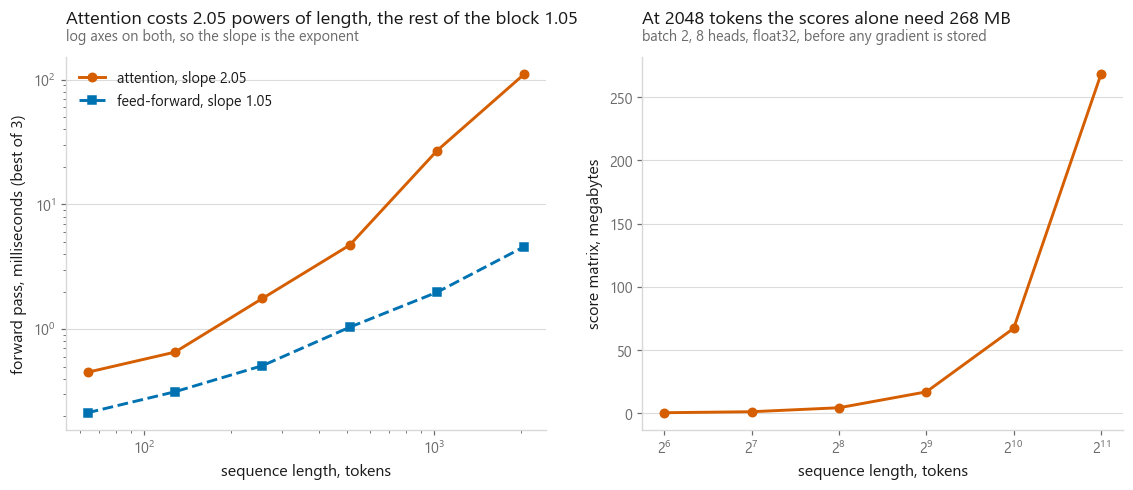

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

axes[0].loglog(timings["sequence length"], timings["attention ms"], color=style.HIGHLIGHT,
               marker=style.MARKERS[0], lw=1.9, label=f"attention, slope {slope_attn:.2f}")
axes[0].loglog(timings["sequence length"], timings["feed-forward ms"], color=style.PALETTE[0],
               ls="--", marker=style.MARKERS[1], lw=1.9,
               label=f"feed-forward, slope {slope_ff:.2f}")
axes[0].set_xlabel("sequence length, tokens")
axes[0].set_ylabel("forward pass, milliseconds (best of 3)")
axes[0].legend(loc="upper left")
style.title(axes[0],
            f"Attention costs {slope_attn:.2f} powers of length, the rest of the block "
            f"{slope_ff:.2f}",
            "log axes on both, so the slope is the exponent")

axes[1].plot(timings["sequence length"], timings["score matrix MB"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], lw=1.9)
axes[1].set_xlabel("sequence length, tokens")
axes[1].set_ylabel("score matrix, megabytes")
axes[1].set_xscale("log", base=2)
style.title(axes[1],
            f"At {LENGTHS[-1]} tokens the scores alone need "
            f"{timings['score matrix MB'].iloc[-1]:.0f} MB",
            f"batch {B_TIME}, {H_TIME} heads, float32, before any gradient is stored")

style.save(fig, FIG / "fig-06-quadratic-cost.png")

The fitted exponents are the honest version of the textbook claim. Attention
comes out near two and the feed-forward network near one, which is what the
arithmetic says. At short lengths neither slope is clean, because at 64 tokens
the work is small enough that Python and kernel launch overhead dominate, which
is also why nobody notices the quadratic term until their context window grows.

The memory panel is the part that bites first in practice. Storing the scores
for backpropagation at long context is what fills a card, and it is why
FlashAttention, which never materialises the full matrix, was a systems paper
with a larger effect on model sizes than most architecture papers.

## 10. When it wins and when it loses

| | |
|---|---|
| **Wins** | Long-range dependencies where the useful token could be anywhere, tasks where retrieval by content beats carrying state, and any setting where training throughput matters, because the sequence axis is parallel |
| **Loses** | Very long sequences, where the $T^2$ term decides everything; small data, because the architecture assumes almost nothing and has to learn what a convolution or a recurrence would have been given; and streaming, where a recurrent state of fixed size is the natural shape |
| **Costs more than it looks** | Every position attends to every position at every layer of every head. The parameter count hides this: the expensive part is an activation, not a weight |

The comparison against [09-04](../04-lstm/) is worth stating carefully rather
than as a slogan. An LSTM's path from an early step to a late one is a product
of one Jacobian per step in between, and that chapter measured how little
survives it. Attention's path is a single operation, so nothing decays, and the
price is that every path exists whether it is useful or not.

## Cheat sheet

| | |
|---|---|
| **Attention** | `softmax(Q @ K.T / sqrt(d_k)) @ V`. Q asks, K advertises, V answers |
| **The scale** | Scores have variance $d_k$ without it. Removing it saturates the softmax at initialisation and the gradient goes with it |
| **Multi-head** | One projection of size $d_{\text{model}}$, reshaped into $h$ heads of width $d_{\text{model}}/h$. Same cost, several lookups |
| **Positional encoding** | Attention is permutation equivariant, measured here at floating point noise on a trained model. Add positions if the answer depends on order, and skip it if it does not |
| **Encoder block** | `x = LN(x + attn(x))` then `x = LN(x + ffn(x))`. Post-norm needs warmup; `norm_first=True` does not |
| **The feed-forward net** | Two thirds of the block's parameters, applied per position, and the only non-linearity between positions' mixtures |
| **Causal mask** | `torch.triu(ones(T, T), 1).bool()`, set to -inf before the softmax. Without it a language model reads the next token and beats the entropy floor |
| **Cost** | Measured exponent near 2 in sequence length for attention, near 1 for everything else. Memory for the scores is $B \cdot h \cdot T^2$ |
| **Sanity checks** | Rows of the weights sum to one; masked entries are exactly zero; a from-scratch block matches `nn.TransformerEncoderLayer` to 1e-7 when the weights are copied across |

## What to remember

1. Attention is a lookup whose match is a similarity rather than an equality, so
   the answer is a weighted blend. When two positions match a query equally, it
   returns their average and reports no problem.
2. The $\sqrt{d_k}$ exists because dot products of $d_k$ random terms have
   variance $d_k$. Without it the softmax saturates before training starts, and a
   saturated softmax has no gradient.
3. Heads are slices of the same width, not extra width. Several lookups for the
   price of one, and the trained model here concentrated the retrieval in a
   small number of them, as the printed table counts.
4. Self-attention has no idea what order its input came in. That is a theorem,
   and shuffling the input of a model trained without positional encodings moved
   its logits by roughly nothing.
5. Positional encodings are needed when the label depends on order. On the task
   here it did not, and adding them changed the final accuracy by nothing worth
   reporting.
6. The feed-forward block is where most of the parameters live and the only place
   a non-linearity is applied to a position's own mixture.
7. A causal mask is one boolean matrix, and leaving it out produces a loss below
   the information-theoretic floor. Suspiciously good training loss on a language
   model is a masking bug until proven otherwise.
8. The quadratic cost is real and measured, near an exponent of two, and the
   memory for the score matrix is what runs out first.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-08 Fine-tuning a transformer](../08-fine-tuning-a-transformer/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Transformer` `#Attention` `#SelfAttention` `#PyTorch`
`#NLP` `#MachineLearning` `#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`